<a href="https://colab.research.google.com/github/SANTHIYAM306/mlops_training_tasks/blob/main/Smart_Factory_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    RPM  Vibration  Pressure Machine_Mode  Temperature  Defective
0  4174      4.835    31.766          Eco        97.75          1
1  4507      4.853    81.235     Standard       128.57          1
2  1860      4.339    79.539     Standard        79.79          0
3  2294      3.044    92.267     Standard        87.09          0
4  2130      3.534    20.679     Standard        54.07          0
MSE: 135.18877867557796


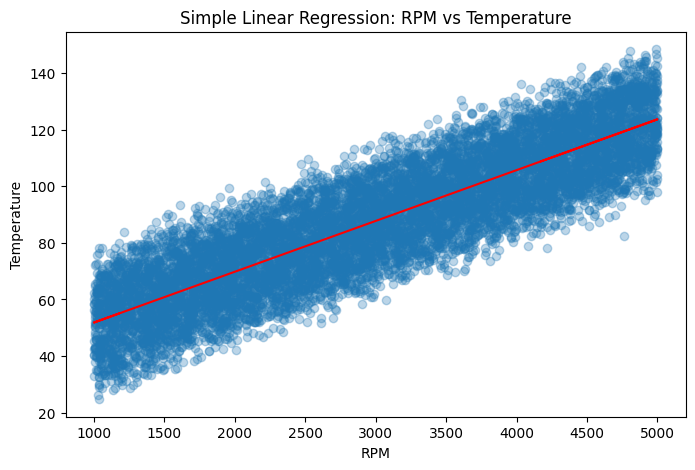

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load the dataset you uploaded to Google Colab
data = pd.read_csv("factory_sensor_data_10000.csv")

# Display first 5 rows
print(data.head())

# Input feature (RPM)
X = data[['RPM']]

# Target variable (Temperature)
y = data['Temperature']

# Create and train the model
model = LinearRegression()
model.fit(X, y)

# Predict temperature
pred = model.predict(X)

# Calculate Mean Squared Error
mse = mean_squared_error(y, pred)

print("MSE:", mse)

# Plot actual data and regression line
plt.figure(figsize=(8, 5))
plt.scatter(data['RPM'], y, alpha=0.3)
plt.plot(data['RPM'], pred, color='red')
plt.xlabel("RPM")
plt.ylabel("Temperature")
plt.title("Simple Linear Regression: RPM vs Temperature")
plt.show()

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Multiple input features
X = data[['RPM', 'Vibration', 'Pressure']]

# Target variable
y = data['Temperature']

# Create model
multi_model = LinearRegression()

# Train model
multi_model.fit(X, y)

# Predict
pred = multi_model.predict(X)

# Calculate MSE
mse = mean_squared_error(y, pred)

print("Multivariable Regression MSE:", mse)

Multivariable Regression MSE: 16.298721539861326


In [4]:
import joblib

# Save the trained model
joblib.dump(multi_model, 'temperature_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [6]:
import joblib
import pandas as pd

loaded_model = joblib.load('temperature_model.pkl')

new_data = pd.DataFrame({
    'RPM': [3000],
    'Vibration': [2.5],
    'Pressure': [60]
})

prediction = loaded_model.predict(new_data)

print("Predicted Temperature:", prediction[0])

Predicted Temperature: 87.3217878518902


In [7]:
# Convert Machine_Mode into binary columns
encoded = pd.get_dummies(
    data,
    columns=['Machine_Mode'],
    drop_first=True
)

# Display first 5 rows
print(encoded.head())

    RPM  Vibration  Pressure  Temperature  Defective  Machine_Mode_High-Speed  \
0  4174      4.835    31.766        97.75          1                    False   
1  4507      4.853    81.235       128.57          1                    False   
2  1860      4.339    79.539        79.79          0                    False   
3  2294      3.044    92.267        87.09          0                    False   
4  2130      3.534    20.679        54.07          0                    False   

   Machine_Mode_Standard  
0                  False  
1                   True  
2                   True  
3                   True  
4                   True  


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Input features (all columns except Temperature and Defective)
X = encoded.drop(['Temperature', 'Defective'], axis=1)

# Target variable
y = encoded['Temperature']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
split_model = LinearRegression()

# Train model
split_model.fit(X_train, y_train)

# Predict on test data
y_pred = split_model.predict(X_test)

# Calculate test MSE
test_mse = mean_squared_error(y_test, y_pred)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Test MSE:", test_mse)

Train shape: (8000, 5)
Test shape: (2000, 5)
Test MSE: 8.813827781597167


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# Input features (exclude target columns)
X = encoded.drop(['Temperature', 'Defective'], axis=1)

# Classification target
y = encoded['Defective']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create classifier
classifier = LogisticRegression(max_iter=1000)

# Train classifier
classifier.fit(X_train, y_train)

# Predict on test data
y_pred = classifier.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("Accuracy:", accuracy)

Confusion Matrix:
[[1197  120]
 [ 186  497]]
Accuracy: 0.847


In [10]:
import joblib
import pandas as pd

# Load saved regression model
model = joblib.load("temperature_model.pkl")

# Unknown machine data
new_machine = pd.DataFrame({
    'RPM': [4200],
    'Vibration': [3.8],
    'Pressure': [75]
})

# Predict temperature
predicted_temperature = model.predict(new_machine)

print("Unknown Machine Data:")
print(new_machine)

print("Predicted Temperature:", predicted_temperature[0])

Unknown Machine Data:
    RPM  Vibration  Pressure
0  4200        3.8        75
Predicted Temperature: 118.93652691072052


In [11]:
import pandas as pd

# New unknown data with Machine Mode
new_part = pd.DataFrame({
    'RPM': [4200],
    'Vibration': [3.8],
    'Pressure': [75],
    'Machine_Mode': ['High-Speed']
})

# Apply one-hot encoding
new_part_encoded = pd.get_dummies(new_part)

# Match training columns
new_part_encoded = new_part_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

# Predict defective or good
result = classifier.predict(new_part_encoded)

if result[0] == 1:
    print("Prediction: Defective Part")
else:
    print("Prediction: Good Part")

Prediction: Defective Part
